## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x00000208024710C0> [RTYPES.NILSXP]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thrace'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2009-2023_filled_meantemps.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2023.csv', encoding=enc)

In [5]:
timeline_file.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall
0,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.027940,41.273060,2009-01-01,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13817.000000,NaN,13817.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.269528
1,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.027940,41.273060,2009-01-02,2009,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13817.000000,13494.000000,13817.000000,NaN,NaN,NaN,13494.000000,NaN,NaN,NaN,0.695428
2,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.027940,41.273060,2009-01-03,2009,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13817.000000,13494.000000,13817.000000,NaN,NaN,NaN,13494.000000,NaN,NaN,NaN,1.744418
3,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.027940,41.273060,2009-01-04,2009,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13817.000000,13494.000000,13817.000000,NaN,NaN,NaN,13494.000000,NaN,NaN,NaN,0.185591
4,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.027940,41.273060,2009-01-05,2009,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13817.000000,13494.000000,13817.000000,NaN,NaN,NaN,13494.000000,NaN,NaN,NaN,0.099521


In [6]:
timeline_file.dt_placement.unique().shape[0] == 5478

True

In [7]:
timeline_file.shape

(3620958, 33)

In [8]:
wnv_file.head()

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,"ανατολικη μακεδονια, θρακη",δραμα,2010-06,0
1,"ανατολικη μακεδονια, θρακη",δραμα,2010-07,0
2,"ανατολικη μακεδονια, θρακη",δραμα,2010-08,0
3,"ανατολικη μακεδονια, θρακη",δραμα,2010-09,0
4,"ανατολικη μακεδονια, θρακη",δραμα,2010-10,0


In [9]:
wnv_file.shape

(250, 4)

In [10]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [11]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)
timeline_file['week'] = timeline_file.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

timeline_file = encode_cyclical(timeline_file, 'day', 31)
timeline_file = encode_cyclical(timeline_file, 'month', 12)
timeline_file = encode_cyclical(timeline_file, 'week', 53)

In [12]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

### Add mosquito predictions from trained model

In [10]:
dataset_list = []
groups = timeline_file.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset_list.append(temp_df)

dataset = pd.concat(dataset_list, ignore_index=True)
dataset.reset_index(drop=True, inplace=True)

In [11]:
dataset.dtypes

NUTS2_ID               object
NUTS2_NAME             object
NUTS3_ID               object
NUTS3_NAME             object
x                     float64
y                     float64
dt_placement           object
year                    int64
month                   int64
day                     int64
ndvi                  float64
ndmi                  float64
ndwi                  float64
ndbi                  float64
ndvi_mean             float64
ndmi_mean             float64
ndwi_mean             float64
ndbi_mean             float64
ndvi_std              float64
ndmi_std              float64
ndwi_std              float64
ndbi_std              float64
lst_day               float64
lst_night             float64
lst_day_jan_mean      float64
lst_day_feb_mean      float64
lst_day_mar_mean      float64
lst_day_apr_mean      float64
lst_night_jan_mean    float64
lst_night_feb_mean    float64
lst_night_mar_mean    float64
lst_night_apr_mean    float64
rainfall              float64
lst       

In [25]:
model = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Scaler.pkl', 'rb'))


In [28]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [29]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [30]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [31]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

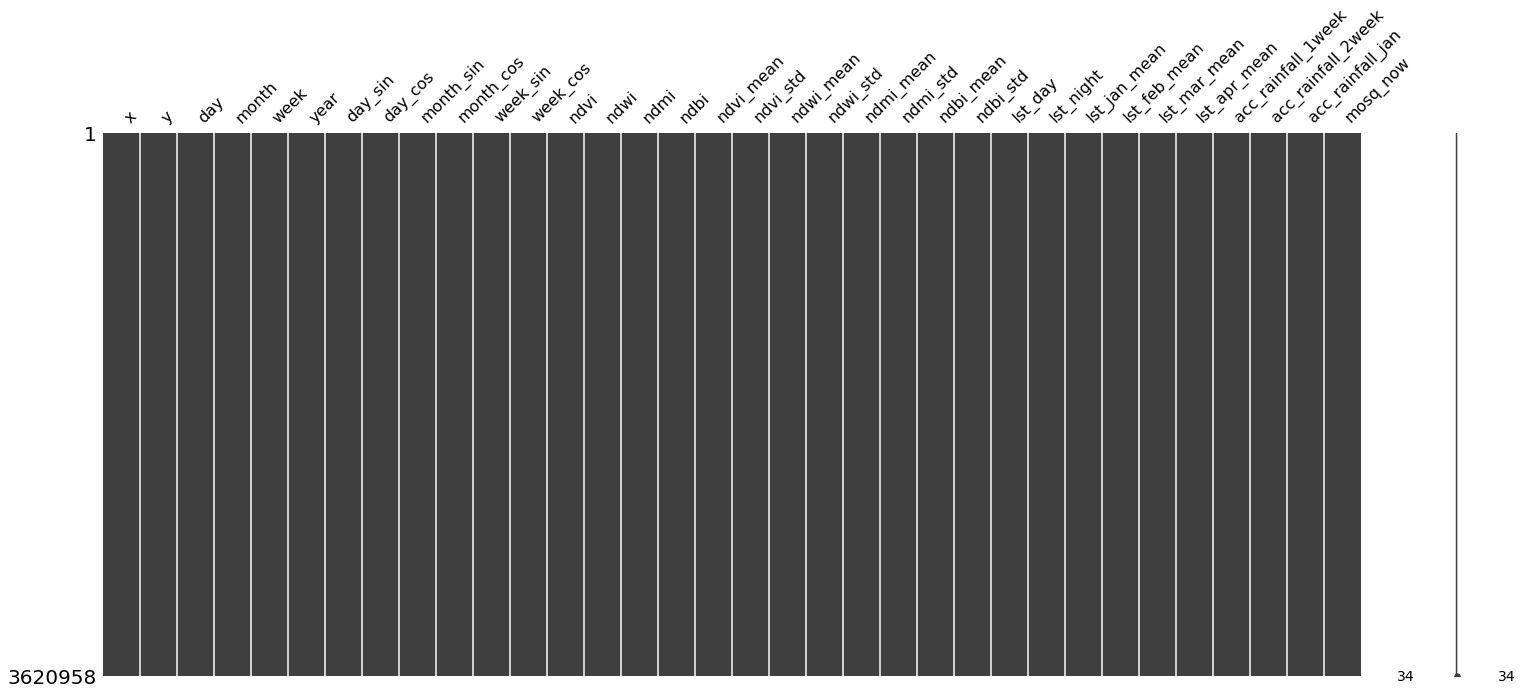

In [32]:
missingno.matrix(dataset_mamoth)

In [33]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [34]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [35]:
predictions = give_predictions(model, dataset_mamoth)

In [36]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,23.694820,41.344930,2009-01-01,1
1,23.694820,41.344930,2009-01-02,1
2,23.694820,41.344930,2009-01-03,1
3,23.694820,41.344930,2009-01-04,1
4,23.694820,41.344930,2009-01-05,1
...,...,...,...,...
3620953,26.605580,41.380340,2023-12-27,1
3620954,26.605580,41.380340,2023-12-28,1
3620955,26.605580,41.380340,2023-12-29,1
3620956,26.605580,41.380340,2023-12-30,1


<AxesSubplot:>

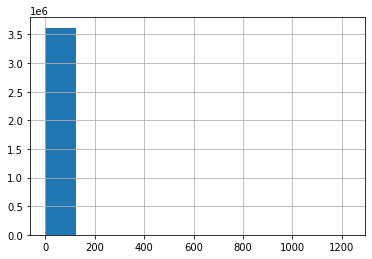

In [37]:
mosqutio_predictions.mosq_pred.hist()

In [13]:
#mosqutio_predictions.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2009_2023.csv", encoding = enc, index = False)

mosqutio_predictions = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2009_2023.csv", encoding = enc)
mosqutio_predictions['dt_placement'] = pd.to_datetime(mosqutio_predictions['dt_placement'])

dataset = timeline_file

In [14]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x', 'y', 'dt_placement'])

### Add Geomorphological and Land Cover/Use

In [15]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred
0,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.027940,41.273060,2009-01-01,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13817.000000,NaN,13817.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.269528,NaN,NaN,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1
1,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.027940,41.273060,2009-01-02,2009,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13817.000000,13494.000000,13817.000000,NaN,NaN,NaN,13494.000000,NaN,NaN,NaN,0.695428,13655.500000,13655.500000,NaN,NaN,NaN,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,1
2,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.027940,41.273060,2009-01-03,2009,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13817.000000,13494.000000,13817.000000,NaN,NaN,NaN,13494.000000,NaN,NaN,NaN,1.744418,13655.500000,13655.500000,NaN,NaN,NaN,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,1
3,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.027940,41.273060,2009-01-04,2009,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13817.000000,13494.000000,13817.000000,NaN,NaN,NaN,13494.000000,NaN,NaN,NaN,0.185591,13655.500000,13655.500000,NaN,NaN,NaN,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,1
4,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.027940,41.273060,2009-01-05,2009,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13817.000000,13494.000000,13817.000000,NaN,NaN,NaN,13494.000000,NaN,NaN,NaN,0.099521,13655.500000,13655.500000,NaN,NaN,NaN,2,0.848644,0.528964,0.500000,0.866025,0.234886,0.972023,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3620953,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.450250,41.091300,2023-12-27,2023,12,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14347.096774,14295.357143,14635.612903,14635.612903,13758.612903,13681.357143,13849.000000,13849.000000,NaN,NaN,14052.854839,13988.357143,14242.306452,14242.306452,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,1
3620954,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.450250,41.091300,2023-12-28,2023,12,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14347.096774,14295.357143,14635.612903,14635.612903,13758.612903,13681.357143,13849.000000,13849.000000,NaN,NaN,14052.854839,13988.357143,14242.306452,14242.306452,52,-0.571268,0.820763,-0.000000,1.000000,-0.118273,0.992981,1
3620955,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.450250,41.091300,2023-12-29,2023,12,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14347.096774,14295.357143,14635.612903,14635.612903,13758.612903,13681.357143,13849.000000,13849.000000,NaN,NaN,14052.854839,13988.357143,14242.306452,14242.306452,52,-0.394356,0.918958,-0.000000,1.000000,-0.118273,0.992981,1
3620956,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.450250,41.091300,2023-12-30,2023,12,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14347.096774,14295.357143,14635.612903,14635.612903,13758.612903,13681.357143,13849.000000,13849.000000,NaN,NaN,14052.854839,13988.357143,14242.306452,14242.306452,52,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981,1


In [16]:
dataset_locations = dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [17]:
dataset_locations_per_year = dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [18]:
dataset_locations

,x,y
0,24.027940,41.273060
1,24.265880,41.524590
2,24.313470,41.093390
3,24.313470,41.129330
4,24.313470,41.165260
...,...,...
656,25.497760,40.911630
657,25.450250,41.235030
658,25.450250,41.199100
659,25.497760,41.199100


In [19]:
dataset_locations_per_year

,x,y,year
0,24.027940,41.273060,2009
1,24.265880,41.524590,2009
2,24.313470,41.093390,2009
3,24.313470,41.129330,2009
4,24.313470,41.165260,2009
...,...,...,...
9910,25.497760,40.911630,2023
9911,25.450250,41.235030,2023
9912,25.450250,41.199100,2023
9913,25.497760,41.199100,2023


In [20]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [21]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 7.073230889886872e-13


In [22]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [23]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,24.027940,41.273060,11987.990076,1067.130546,10,142.065611,923.254203,158.800662,0.000000,2.000000
1,24.265880,41.524590,16369.142322,1856.449582,9,244.075329,1549.244078,197.235047,0.000000,1.702251
2,24.313470,41.093390,18959.391610,509.233048,22,115.153728,265.786471,190.749528,0.000000,21.704106
3,24.313470,41.129330,19401.888015,2274.776766,21,268.051743,291.929017,201.263296,0.000000,15.064176
4,24.313470,41.165260,15411.421403,697.215110,11,152.780939,238.968822,175.543130,0.000000,1.461254
...,...,...,...,...,...,...,...,...,...,...
656,25.497760,40.911630,2966.323382,187.957252,7,248.265437,71.218311,184.863516,0.000000,38.016013
657,25.450250,41.235030,25020.531044,1245.958165,18,274.634861,559.373569,196.075052,0.000000,2.286492
658,25.450250,41.199100,25707.135863,895.067645,12,169.978506,330.484337,194.672886,0.000000,1.468754
659,25.497760,41.199100,27678.461924,1449.572462,10,113.129414,342.938937,168.468395,0.000000,1.788158


In [24]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [25]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [26]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [27]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,24.027940,41.273060,11987.990076,1067.130546,10,142.065611,923.254203,158.800662,0.000000,2.000000
1,24.265880,41.524590,16369.142322,1856.449582,9,244.075329,1549.244078,197.235047,0.000000,1.702251
2,24.313470,41.093390,18959.391610,509.233048,22,115.153728,265.786471,190.749528,0.000000,21.704106
3,24.313470,41.129330,19401.888015,2274.776766,21,268.051743,291.929017,201.263296,0.000000,15.064176
4,24.313470,41.165260,15411.421403,697.215110,11,152.780939,238.968822,175.543130,0.000000,1.461254
...,...,...,...,...,...,...,...,...,...,...
656,25.497760,40.911630,2966.323382,187.957252,7,248.265437,71.218311,184.863516,0.000000,38.016013
657,25.450250,41.235030,25020.531044,1245.958165,18,274.634861,559.373569,196.075052,0.000000,2.286492
658,25.450250,41.199100,25707.135863,895.067645,12,169.978506,330.484337,194.672886,0.000000,1.468754
659,25.497760,41.199100,27678.461924,1449.572462,10,113.129414,342.938937,168.468395,0.000000,1.788158


In [29]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [30]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [31]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [32]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [33]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [34]:
landcover_2023 = landcover_2022

In [35]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2009
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2010
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2011
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2012
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2013
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2014
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2015
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2016
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2017
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2018
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2019
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2020
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2021
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2022
Min distance: 0.0
Max distance: 7.073230889886872e-13
Year: 2023
Min distance: 0.0
Max distance: 7.073230889886872e-13


In [36]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [37]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,24.027940,41.273060,2009,31,92,30,92.000000,30,92,10,10,1,6,6,2,0
1,24.265880,41.524590,2009,11,99,10,99.000000,10,99,1,1,7,1,1,2,0
2,24.313470,41.093390,2009,22,87,20,87.000000,20,87,9,9,4,4,4,2,0
3,24.313470,41.129330,2009,22,82,20,82.000000,20,82,9,9,4,1,1,2,0
4,24.313470,41.165260,2009,31,88,36,79.000000,30,88,12,12,3,5,8,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9910,25.497760,40.911630,2023,31,88,30,88.000000,30,88,10,10,1,6,6,2,0
9911,25.450250,41.235030,2023,22,75,20,75.000000,20,75,9,9,4,4,4,2,0
9912,25.450250,41.199100,2023,22,84,20,84.000000,20,84,9,9,4,4,4,2,0
9913,25.497760,41.199100,2023,22,81,20,81.000000,20,81,9,9,4,1,1,2,0


In [38]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int64
lc_prop1                 int64
lc_prop1_assessment      int64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment      int64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [39]:
dataset = pd.merge(dataset, dataset_geo, on=['x', 'y'], how='left')

In [40]:
dataset = pd.merge(dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

In [41]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.027940,41.273060,2009-01-01,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13817.000000,NaN,13817.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.269528,NaN,NaN,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,11987.990076,1067.130546,10,142.065611,923.254203,158.800662,0.000000,2.000000,31,92,30,92.000000,30,92,10,10,1,6,6,2,0
1,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.027940,41.273060,2009-01-02,2009,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13817.000000,13494.000000,13817.000000,NaN,NaN,NaN,13494.000000,NaN,NaN,NaN,0.695428,13655.500000,13655.500000,NaN,NaN,NaN,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,1,11987.990076,1067.130546,10,142.065611,923.254203,158.800662,0.000000,2.000000,31,92,30,92.000000,30,92,10,10,1,6,6,2,0
2,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.027940,41.273060,2009-01-03,2009,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13817.000000,13494.000000,13817.000000,NaN,NaN,NaN,13494.000000,NaN,NaN,NaN,1.744418,13655.500000,13655.500000,NaN,NaN,NaN,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,1,11987.990076,1067.130546,10,142.065611,923.254203,158.800662,0.000000,2.000000,31,92,30,92.000000,30,92,10,10,1,6,6,2,0
3,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.027940,41.273060,2009-01-04,2009,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13817.000000,13494.000000,13817.000000,NaN,NaN,NaN,13494.000000,NaN,NaN,NaN,0.185591,13655.500000,13655.500000,NaN,NaN,NaN,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,1,11987.990076,1067.130546,10,142.065611,923.254203,158.800662,0.000000,2.000000,31,92,30,92.000000,30,92,10,10,1,6,6,2,0
4,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.027940,41.273060,2009-01-05,2009,1,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13817.000000,13494.000000,13817.000000,NaN,NaN,NaN,13494.000000,NaN,NaN,NaN,0.099521,13655.500000,13655.500000,NaN,NaN,NaN,2,0.848644,0.528964,0.500000,0.866025,0.234886,0.972023,1,11987.990076,1067.130546,10,142.065611,923.254203,158.800662,0.000000,2.000000,31,92,30,92.000000,30,92,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3620953,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.450250,41.091300,2023-12-27,2023,12,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14347.096774,14295.357143,14635.612903,14635.612903,13758.612903,13681.357143,13849.000000,13849.000000,NaN,NaN,14052.854839,13988.357143,14242.306452,14242.306452,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,1,15818.177170,1728.357529,3,259.912161,74.844601,181.692960,0.000000,1.000000,31,94,36,92.000000,30,94,12,12,3,5,8,2,0
3620954,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.450250,41.091300,2023-12-28,2023,12,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14347.096774,14295.357143,14635.612903,14635.612903,13758.612903,13681.357143,13849.000000,13849.000000,NaN,NaN,14052.854839,13988.357143,14242.306452,14242.306452,52,-0.571268,0.820763,-0.0000

In [42]:
grouped_by_nuts3 = dataset.groupby(['dt_placement', 'NUTS2_ID',	'NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

In [43]:
grouped_by_nuts3_mods = grouped_by_nuts3.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()

In [44]:
grouped_by_nuts3_mean = grouped_by_nuts3.mean()
grouped_by_nuts3_min = grouped_by_nuts3.min()
grouped_by_nuts3_max = grouped_by_nuts3.max()
grouped_by_nuts3_std = grouped_by_nuts3.std()

In [45]:
grouped_by_nuts3_min.rename(columns={'distance_to_coast': 'distance_to_coast_min', 'distance_to_river': 'distance_to_river_min', 
                                     'slope_mean_1km': 'slope_mean_1km_min', 'aspect_mean_200m': 'aspect_mean_200m_min', 
                                     'elevation_mean_1km': 'elevation_mean_1km_min', 'hillshade_mean_1km': 'hillshade_mean_1km_min',
                                     'fs_area_1km': 'fs_area_1km_min', 'flow_accu_200m': 'flow_accu_200m_min'}, inplace=True)

grouped_by_nuts3_max.rename(columns={'distance_to_coast': 'distance_to_coast_max', 'distance_to_river': 'distance_to_river_max', 
                                     'slope_mean_1km': 'slope_mean_1km_max', 'aspect_mean_200m': 'aspect_mean_200m_max', 
                                     'elevation_mean_1km': 'elevation_mean_1km_max', 'hillshade_mean_1km': 'hillshade_mean_1km_max',
                                     'fs_area_1km': 'fs_area_1km_max', 'flow_accu_200m': 'flow_accu_200m_max'}, inplace=True)

grouped_by_nuts3_std.rename(columns={'distance_to_coast': 'distance_to_coast_std', 'distance_to_river': 'distance_to_river_std', 
                                     'slope_mean_1km': 'slope_mean_1km_std', 'aspect_mean_200m': 'aspect_mean_200m_std', 
                                     'elevation_mean_1km': 'elevation_mean_1km_std', 'hillshade_mean_1km': 'hillshade_mean_1km_std',
                                     'fs_area_1km': 'fs_area_1km_std', 'flow_accu_200m': 'flow_accu_200m_std'}, inplace=True)

In [46]:
grouped_by_nuts3_mods.drop(columns=['index'], inplace = True)

In [47]:
grouped_by_nuts3_mods

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.228140,40.913200,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13924.000000,13420.000000,13924.000000,NaN,NaN,NaN,13420.000000,NaN,NaN,NaN,0.000000,13655.500000,13655.500000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,352.814714,2.251510,2,43.594740,1.494305,131.360703,0.000000,1.000000,31,97,36,98.000000,30,97,12,12,3,5,8,2,0
1,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.823170,41.271320,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13751.000000,13483.000000,13751.000000,NaN,NaN,NaN,13483.000000,NaN,NaN,NaN,0.079310,13752.500000,13752.500000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,1422.320233,2.995414,2,68.560816,3.374522,142.346950,0.000000,1.000000,31,95,36,81.000000,30,95,12,12,3,4,4,2,0
2,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.592780,41.127230,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13817.000000,13131.000000,13817.000000,NaN,NaN,NaN,13131.000000,NaN,NaN,NaN,0.000000,13738.000000,13738.000000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,309.608445,13.084090,2,51.239071,2.443469,158.496367,0.000000,1.000000,31,96,36,96.000000,30,96,12,12,3,5,8,2,0
3,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.123120,41.344930,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13817.000000,13110.000000,13817.000000,NaN,NaN,NaN,13110.000000,NaN,NaN,NaN,0.131764,13398.000000,13398.000000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,0.000000,43.608835,1,23.772370,52.039252,124.148070,0.000000,1.000000,31,98,10,99.000000,10,98,4,4,6,4,4,2,0
4,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",24.641600,41.006750,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13957.000000,13381.000000,13957.000000,NaN,NaN,NaN,13381.000000,NaN,NaN,NaN,1.424114,13578.000000,13578.000000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,1839.000704,25.345187,2,55.369486,3.090786,141.309259,0.000000,1.000000,31,99,20,99.000000,30,99,9,9,4,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27385,2023-12-31,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.228140,40.913200,2023,12,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14211.806452,14125.321429,14278.161290,14278.161290,13782.419355,13656.357143,13800.193548,13800.193548,NaN,NaN,14020.645161,13813.428571,14157.967742,14157.967742,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,1,352.814714,2.251510,2,43.594740,1.494305,131.360703,0.000000,1.000000,31,98,36,98.000000,30,98,12,12,3,5,8,2,0
27386,2023-12-31,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.823170,41.271320,2023,12,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13716.451613,13787.037037,14143.258065,14143.258065,13703.419355,13622.357143,13837.193548,13837.193548,NaN,NaN,13724.419355,13669.393519,13914.548387,13914.548387,52,-0.000000,1.000000,-0.000000,1.000000

In [48]:
grouped_by_nuts3_min

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,year,month,day,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,25.567630,40.446070,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13700.000000,13118.000000,13700.000000,NaN,NaN,NaN,13118.000000,NaN,NaN,NaN,0.000000,13552.500000,13552.500000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,11,68,9,68.000000,10,68,1,1,1,1,1,2,0
1,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.633130,40.911990,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13667.000000,13279.000000,13667.000000,NaN,NaN,NaN,13279.000000,NaN,NaN,NaN,0.006924,13565.000000,13565.000000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,14,70,9,63.000000,10,70,4,4,1,1,1,2,0
2,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.117680,40.911630,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13644.000000,13131.000000,13644.000000,NaN,NaN,NaN,13131.000000,NaN,NaN,NaN,0.000000,13558.500000,13558.500000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.000000,1.000000,11,66,9,66.000000,10,66,1,1,1,1,1,2,0
3,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,23.694820,41.057460,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13397.000000,13110.000000,13397.000000,NaN,NaN,NaN,13110.000000,NaN,NaN,NaN,0.006744,13398.000000,13398.000000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,0.000000,43.608835,0,23.772370,52.039252,124.148070,0.000000,1.000000,11,67,9,67.000000,10,67,1,1,1,1,1,1,0
4,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",23.932150,40.647420,2009,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13675.000000,13381.000000,13675.000000,NaN,NaN,NaN,13381.000000,NaN,NaN,NaN,0.121880,13578.000000,13578.000000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,1839.000704,25.345187,0,55.369486,3.090786,141.309259,0.000000,1.000000,11,67,9,67.000000,10,65,1,1,1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27385,2023-12-31,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,25.567630,40.446070,2023,12,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13806.387097,14009.464286,14278.161290,14278.161290,13629.709677,13554.928571,13746.774194,13746.774194,NaN,NaN,13790.451613,13813.428571,14045.661290,14045.661290,52,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,1,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,1,65,1,65.000000,1,65,1,1,1,1,1,2,0
27386,2023-12-31,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.633130,40.911990,2023,12,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13716.451613,13787.037037,14143.258065,14143.258065,13703.419355,13551.750000,13685.838710,13685.838710,NaN,NaN,13724.419355,13669.393519,13914.548387,13914.548387,52,-0.000000,1.000000,-0

In [49]:
grouped_by_nuts3_dataset = pd.concat([grouped_by_nuts3_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_nuts3_mean[['x','y']],
                                     grouped_by_nuts3_mods[['day','month','year','week']],
                                     grouped_by_nuts3_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_nuts3_mean[['lst_day','lst_night','lst', 'rainfall','mosq_pred']],
                                     grouped_by_nuts3_mean[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_nuts3_min[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_nuts3_max[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_nuts3_std[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_nuts3_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']]], axis=1)

In [50]:
grouped_by_nuts3_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw
0,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13916.041026,13425.014286,13662.800000,0.217947,1.000000,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2
1,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13903.037500,13464.444444,13705.611111,0.084414,1.000000,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2
2,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13943.785714,13464.769231,13718.307692,0.035072,1.000000,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.000000,1.000000,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,31,36,30,12,12,3,5,8,2
3,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13772.444444,13241.333333,13506.000000,1.263294,1.052632,10235.211338,1347.266180,14.339181,175.649354,681.171727,179.960721,0.000059,93.338294,0.000000,43.608835,0,23.772370,52.039252,124.148070,0.000000,1.000000,28860.376246,4375.975742,41,306.695151,1723.218614,228.093830,0.004051,4600.484970,6661.726102,977.423359,9.648629,60.382682,380.392072,15.747938,0.000407,492.988002,31,10,10,4,4,6,4,4,2
4,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",24.438568,40.915602,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13917.972603,13447.250000,13648.375000,1.700455,1.012195,8651.285469,1674.007433,13.512195,173.904275,330.955393,177.973580,0.000000,38.994123,1839.000704,25.345187,0,55.369486,3.090786,141.309259,0.000000,1.000000,22997.694489,4368.814291,36,308.655114,873.992425,198.179292,0.000000,938.823417,5082.728847,1194.057645,9.940867,60.173946,241.561441,11.893370,0.000000,130.863872,31,20,30,9,9,4,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27385,2023-12-31,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,31,12,202

<AxesSubplot:>

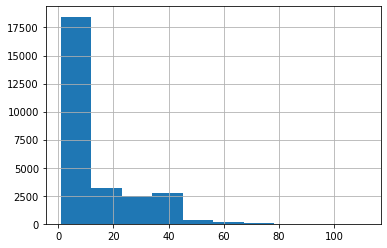

In [51]:
grouped_by_nuts3_dataset.mosq_pred.hist()

In [52]:
grouped_by_nuts3_dataset = convert_temperature(grouped_by_nuts3_dataset)

<AxesSubplot:>

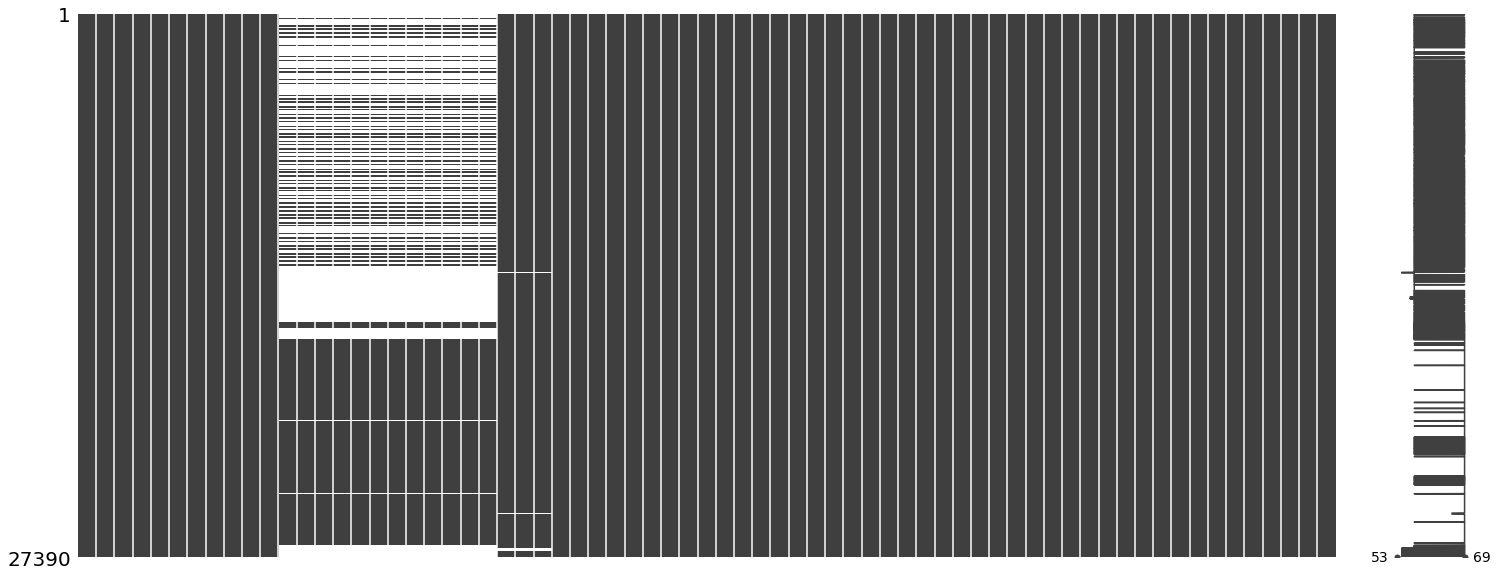

In [53]:
missingno.matrix(grouped_by_nuts3_dataset)

### Add Bio Variables ###

In [54]:
bio_values = []

for region in grouped_by_nuts3_dataset.NUTS3_NAME.unique():
    for year in grouped_by_nuts3_dataset.year.unique():
        for month in grouped_by_nuts3_dataset.month.unique():
            filtered_df = grouped_by_nuts3_dataset.loc[(grouped_by_nuts3_dataset['year'] == year) & (grouped_by_nuts3_dataset['NUTS3_NAME'] == region) & (grouped_by_nuts3_dataset['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'NUTS3_NAME': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [55]:
bio_values_df = pd.DataFrame(bio_values)

In [56]:
bio_values_df

,NUTS3_NAME,year,month,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,εβρος,2009,1,-8.242326,9.934900,218.119280
1,εβρος,2009,2,-3.492200,13.199800,186.450036
2,εβρος,2009,3,-2.876935,19.316700,153.808939
3,εβρος,2009,4,1.371400,26.142700,59.363722
4,εβρος,2009,5,6.757700,32.421500,68.970532
...,...,...,...,...,...,...
895,"θασος, καβαλα",2023,8,19.010000,36.272683,8.348822
896,"θασος, καβαλα",2023,9,17.865122,31.613415,17.004900
897,"θασος, καβαλα",2023,10,11.397619,27.738571,39.118780
898,"θασος, καβαλα",2023,11,-0.034286,21.269524,104.891445


In [57]:
dataset = pd.merge(grouped_by_nuts3_dataset, bio_values_df, on=['NUTS3_NAME', 'year', 'month'], how='left')

In [58]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.170821,-4.649714,0.260553,0.217947,1.000000,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-8.242326,9.934900,218.119280
1,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.910750,-3.861111,0.524819,0.084414,1.000000,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2,-5.288987,12.493000,303.539567
2,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.725714,-3.854615,0.935549,0.035072,1.000000,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.000000,1.000000,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,31,36,30,12,12,3,5,8,2,-4.623871,12.565323,265.761927
3,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.298889,-8.323333,-3.012222,1.263294,1.052632,10235.211338,1347.266180,14.339181,175.649354,681.171727,179.960721,0.000059,93.338294,0.000000,43.608835,0,23.772370,52.039252,124.148070,0.000000,1.000000,28860.376246,4375.975742,41,306.695151,1723.218614,228.093830,0.004051,4600.484970,6661.726102,977.423359,9.648629,60.382682,380.392072,15.747938,0.000407,492.988002,31,10,10,4,4,6,4,4,2,-8.323333,9.517239,281.072503
4,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",24.438568,40.915602,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.209452,-4.205000,0.502226,1.700455,1.012195,8651.285469,1674.007433,13.512195,173.904275,330.955393,177.973580,0.000000,38.994123,1839.000704,25.345187,0,55.369486,3.090786,141.309259,0.000000,1.000000,22997.694489,4368.814291,36,308.655114,873.992425,198.179292,0.000000,938.823417,5082.728847,1194.057645,9.940867,60.173946,241.561441,11.893370,0.000000,130.863872,31,20,30,9,9,4,1,1,2,-4.205000,13.500000,282.104102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

<AxesSubplot:>

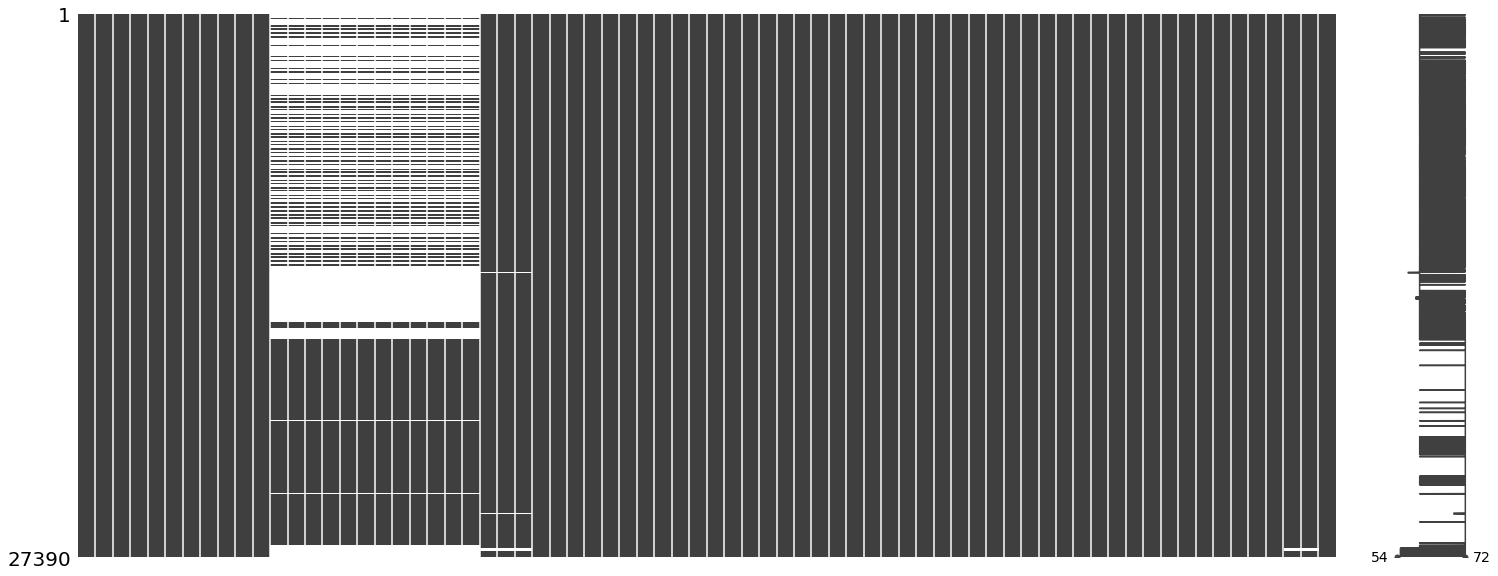

In [59]:
missingno.matrix(dataset)

In [60]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [61]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [62]:
dataset

,dt_placement_daily,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.170821,-4.649714,0.260553,0.217947,1.000000,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-8.242326,9.934900,218.119280,2009-01
1,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.910750,-3.861111,0.524819,0.084414,1.000000,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2,-5.288987,12.493000,303.539567,2009-01
2,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.725714,-3.854615,0.935549,0.035072,1.000000,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.000000,1.000000,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,31,36,30,12,12,3,5,8,2,-4.623871,12.565323,265.761927,2009-01
3,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.298889,-8.323333,-3.012222,1.263294,1.052632,10235.211338,1347.266180,14.339181,175.649354,681.171727,179.960721,0.000059,93.338294,0.000000,43.608835,0,23.772370,52.039252,124.148070,0.000000,1.000000,28860.376246,4375.975742,41,306.695151,1723.218614,228.093830,0.004051,4600.484970,6661.726102,977.423359,9.648629,60.382682,380.392072,15.747938,0.000407,492.988002,31,10,10,4,4,6,4,4,2,-8.323333,9.517239,281.072503,2009-01
4,2009-01-01,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",24.438568,40.915602,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.209452,-4.205000,0.502226,1.700455,1.012195,8651.285469,1674.007433,13.512195,173.904275,330.955393,177.973580,0.000000,38.994123,1839.000704,25.345187,0,55.369486,3.090786,141.309259,0.000000,1.000000,22997.694489,4368.814291,36,308.655114,873.992425,198.179292,0.000000,938.823417,5082.728847,1194.057645,9.940867,60.173946,241.561441,11.893370,0.000000,130.863872,31,20,30,9,9,4,1,1,2,-4.205000,13.500000,282.104102,2009-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [63]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

grouped_by_month_mods = grouped_by_month.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()

grouped_by_month_mods

,index,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,0,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.170821,-4.706389,0.232216,0.000000,1.000000,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-8.242326,9.934900,218.119280
1,1,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.910750,-3.861111,0.524819,0.000000,1.000000,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2,-5.288987,12.493000,303.539567
2,2,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.725714,-4.044286,0.840714,0.000000,1.000000,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.000000,1.000000,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,31,36,30,12,12,3,5,8,2,-4.623871,12.565323,265.761927
3,3,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,1,1,2009,2,0.127943,0.355711,0.247755,-0.355711,0.112507,0.361166,0.255837,-0.361166,0.035535,0.071643,0.097632,0.071643,2.298889,-0.657531,-1.154686,0.000000,1.005848,10235.211338,1347.266180,14.339181,175.649354,681.171727,179.960721,0.000059,93.338294,0.000000,43.608835,0,23.772370,52.039252,124.148070,0.000000,1.000000,28860.376246,4375.975742,41,306.695151,1723.218614,228.093830,0.004051,4600.484970,6661.726102,977.423359,9.648629,60.382682,380.392072,15.747938,0.000407,492.988002,31,10,10,4,4,6,4,4,2,-8.323333,9.517239,281.072503
4,4,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",24.438568,40.915602,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.209452,-1.359000,1.925226,0.000000,1.000000,8651.285469,1674.007433,13.512195,173.904275,330.955393,177.973580,0.000000,38.994123,1839.000704,25.345187,0,55.369486,3.090786,141.309259,0.000000,1.000000,22997.694489,4368.814291,36,308.655114,873.992425,198.179292,0.000000,938.823417,5082.728847,1194.057645,9.940867,60.173946,241.561441,11.893370,0.000000,130.863872,31,20,30,9,9,4,1,1,2,-4.205000,13.500000,282.104102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [64]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_month_mean[['x','y']],
                                     grouped_by_month_mods[['month','year']],
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std','lst_day','lst_night','lst','rainfall']],
                                     grouped_by_month_sum[['mosq_pred']],
                                     grouped_by_month_mods[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_month_mods[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_month_mods[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_month_mods[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_month_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']],
                                     grouped_by_month_mods[['monthly_lst_min','monthly_lst_max','monthly_acc_prec']]], axis=1)

In [65]:
grouped_by_month_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.293398,-1.643682,1.824858,7.036106,31.387255,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-8.242326,9.934900,218.119280
1,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.769895,-1.152583,2.808656,9.791599,31.000000,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2,-5.288987,12.493000,303.539567
2,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.184231,-0.670160,3.257036,8.572965,31.000000,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.000000,1.000000,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,31,36,30,12,12,3,5,8,2,-4.623871,12.565323,265.761927
3,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,1,2009,0.127943,0.355711,0.247755,-0.355711,0.112507,0.361166,0.255837,-0.361166,0.035535,0.071643,0.097632,0.071643,4.705082,-2.016578,1.344252,9.066855,33.251462,10235.211338,1347.266180,14.339181,175.649354,681.171727,179.960721,0.000059,93.338294,0.000000,43.608835,0,23.772370,52.039252,124.148070,0.000000,1.000000,28860.376246,4375.975742,41,306.695151,1723.218614,228.093830,0.004051,4600.484970,6661.726102,977.423359,9.648629,60.382682,380.392072,15.747938,0.000407,492.988002,31,10,10,4,4,6,4,4,2,-8.323333,9.517239,281.072503
4,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",24.438568,40.915602,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.936938,0.609741,3.773339,9.100132,31.231707,8651.285469,1674.007433,13.512195,173.904275,330.955393,177.973580,0.000000,38.994123,1839.000704,25.345187,0,55.369486,3.090786,141.309259,0.000000,1.000000,22997.694489,4368.814291,36,308.655114,873.992425,198.179292,0.000000,938.823417,5082.728847,1194.057645,9.940867,60.173946,241.561441,11.893370,0.000000,130.863872,31,20,30,9,9,4,1,1,2,-4.205000,13.500000,282.104102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [66]:
wnv_file.head(5)

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,"ανατολικη μακεδονια, θρακη",δραμα,2010-06,0
1,"ανατολικη μακεδονια, θρακη",δραμα,2010-07,0
2,"ανατολικη μακεδονια, θρακη",δραμα,2010-08,0
3,"ανατολικη μακεδονια, θρακη",δραμα,2010-09,0
4,"ανατολικη μακεδονια, θρακη",δραμα,2010-10,0


In [67]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            900 non-null    period[M]
 1   NUTS2_ID                900 non-null    object   
 2   NUTS2_NAME              900 non-null    object   
 3   NUTS3_ID                900 non-null    object   
 4   NUTS3_NAME              900 non-null    object   
 5   x                       900 non-null    float64  
 6   y                       900 non-null    float64  
 7   month                   900 non-null    int64    
 8   year                    900 non-null    int64    
 9   ndvi                    811 non-null    float64  
 10  ndmi                    811 non-null    float64  
 11  ndwi                    811 non-null    float64  
 12  ndbi                    811 non-null    float64  
 13  ndvi_mean               811 non-null    float64  
 14  ndmi_mean 

In [68]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   NUTS2_NAME    250 non-null    object
 1   NUTS3_NAME    250 non-null    object
 2   dt_placement  250 non-null    object
 3   cases         250 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 7.9+ KB


In [69]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [70]:
wnv_file

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,"ανατολικη μακεδονια, θρακη",δραμα,2010-06,0
1,"ανατολικη μακεδονια, θρακη",δραμα,2010-07,0
2,"ανατολικη μακεδονια, θρακη",δραμα,2010-08,0
3,"ανατολικη μακεδονια, θρακη",δραμα,2010-09,0
4,"ανατολικη μακεδονια, θρακη",δραμα,2010-10,0
...,...,...,...,...
245,"ανατολικη μακεδονια, θρακη",ροδοπη,2023-06,0
246,"ανατολικη μακεδονια, θρακη",ροδοπη,2023-07,0
247,"ανατολικη μακεδονια, θρακη",ροδοπη,2023-08,1
248,"ανατολικη μακεδονια, θρακη",ροδοπη,2023-09,0


In [71]:
wnv_file['cases'].value_counts()

0     187
1      22
3      11
2      10
5       5
7       3
4       2
9       2
10      2
6       1
16      1
11      1
23      1
38      1
21      1
Name: cases, dtype: int64

In [72]:
wnv_file.cases.sum()

282

In [73]:
merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'NUTS3_NAME', 'NUTS2_NAME'] )

In [74]:
merged

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.293398,-1.643682,1.824858,7.036106,31.387255,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-8.242326,9.934900,218.119280,NaN
1,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.769895,-1.152583,2.808656,9.791599,31.000000,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2,-5.288987,12.493000,303.539567,NaN
2,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.184231,-0.670160,3.257036,8.572965,31.000000,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.000000,1.000000,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,31,36,30,12,12,3,5,8,2,-4.623871,12.565323,265.761927,NaN
3,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,1,2009,0.127943,0.355711,0.247755,-0.355711,0.112507,0.361166,0.255837,-0.361166,0.035535,0.071643,0.097632,0.071643,4.705082,-2.016578,1.344252,9.066855,33.251462,10235.211338,1347.266180,14.339181,175.649354,681.171727,179.960721,0.000059,93.338294,0.000000,43.608835,0,23.772370,52.039252,124.148070,0.000000,1.000000,28860.376246,4375.975742,41,306.695151,1723.218614,228.093830,0.004051,4600.484970,6661.726102,977.423359,9.648629,60.382682,380.392072,15.747938,0.000407,492.988002,31,10,10,4,4,6,4,4,2,-8.323333,9.517239,281.072503,NaN
4,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL515,"θασος, καβαλα",24.438568,40.915602,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.936938,0.609741,3.773339,9.100132,31.231707,8651.285469,1674.007433,13.512195,173.904275,330.955393,177.973580,0.000000,38.994123,1839.000704,25.345187,0,55.369486,3.090786,141.309259,0.000000,1.000000,22997.694489,4368.814291,36,308.655114,873.992425,198.179292,0.000000,938.823417,5082.728847,1194.057645,9.940867,60.173946,241.561441,11.893370,0.000000,130.863872,31,20,30,9,9,4,1,1,2,-4.205000,13.500000,282.104102,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [75]:
merged = fillna(merged,{'cases': 0})

In [76]:
merged['cases'].value_counts()

0.000000     837
1.000000      22
3.000000      11
2.000000      10
5.000000       5
7.000000       3
9.000000       2
10.000000      2
4.000000       2
38.000000      1
16.000000      1
6.000000       1
11.000000      1
21.000000      1
23.000000      1
Name: cases, dtype: int64

In [77]:
merged.cases.sum()

282.0

In [78]:
merged = merged.astype({'cases': 'int'})

<AxesSubplot:>

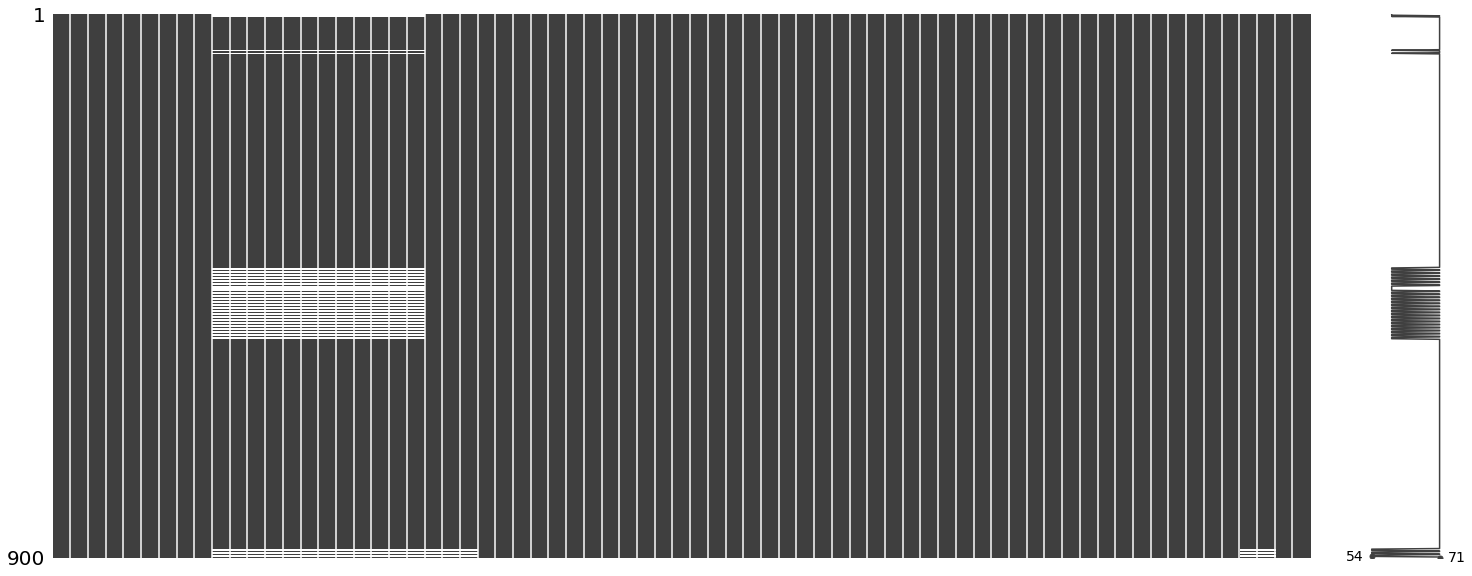

In [79]:
missingno.matrix(merged)

In [80]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

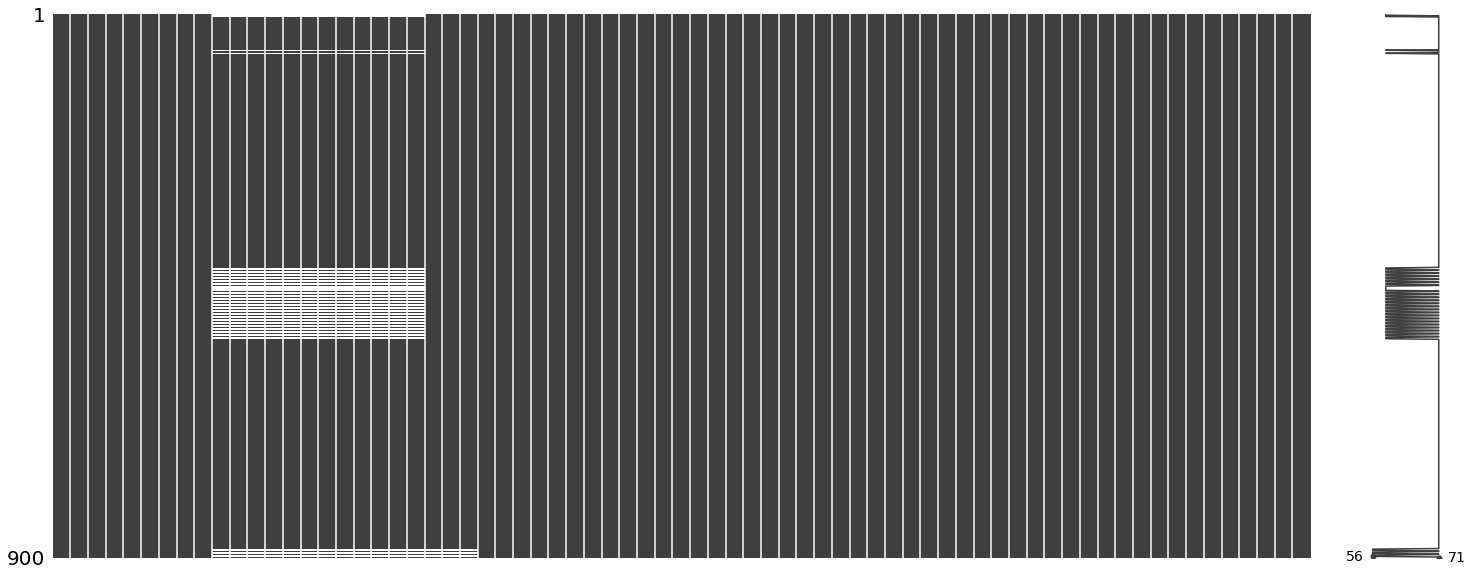

In [81]:
missingno.matrix(merged)

In [82]:
years = merged.year.unique()
years

array([2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023], dtype=int64)

In [83]:
nuts3_units = merged.NUTS3_NAME.unique()
nuts3_units

array(['εβρος', 'ξανθη', 'ροδοπη', 'δραμα', 'θασος, καβαλα'], dtype=object)

In [84]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [85]:
biovars_df.head(20)

,NUTS3_NAME,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,εβρος,2009,15.333333,21.500000,43.877551,925.726578,41.000000,-8.000000,49.000000,4.333333,26.666667,26.666667,4.333333,1688.000000,361.000000,6.000000,66.840173,765.000000,161.000000,161.000000,765.000000
1,ξανθη,2009,14.541667,18.916667,46.138211,792.137021,36.000000,-5.000000,41.000000,5.333333,23.833333,24.000000,5.333333,1700.000000,303.000000,30.000000,59.851570,735.000000,222.000000,237.000000,623.000000
2,ροδοπη,2009,15.750000,20.500000,46.590909,890.735141,40.000000,-4.000000,44.000000,5.500000,26.666667,26.666667,5.333333,1648.000000,339.000000,9.000000,66.126590,772.000000,158.000000,158.000000,603.000000
3,δραμα,2009,12.750000,18.333333,42.635659,817.284862,35.000000,-8.000000,43.000000,3.000000,22.500000,22.500000,3.000000,1562.000000,281.000000,67.000000,53.226270,609.000000,267.000000,322.000000,609.000000
4,"θασος, καβαλα",2009,15.125000,18.416667,44.918699,803.154293,37.000000,-4.000000,41.000000,5.833333,24.500000,24.833333,5.833333,1505.000000,311.000000,37.000000,67.336002,690.000000,201.000000,220.000000,690.000000
5,εβρος,2010,15.958333,21.083333,47.916667,819.217568,39.000000,-5.000000,44.000000,6.333333,25.166667,26.000000,6.333333,1825.000000,417.000000,7.000000,75.307618,787.000000,216.000000,260.000000,787.000000
6,ξανθη,2010,15.041667,19.083333,46.544715,780.285010,35.000000,-6.000000,41.000000,5.333333,24.000000,24.500000,5.333333,1731.000000,402.000000,19.000000,71.172803,649.000000,273.000000,334.000000,649.000000
7,ροδοπη,2010,15.958333,20.250000,46.022727,872.159893,39.000000,-5.000000,44.000000,5.166667,25.833333,26.666667,5.166667,1714.000000,413.000000,11.000000,77.362224,673.000000,246.000000,275.000000,673.000000
8,δραμα,2010,13.166667,17.833333,44.583333,794.965217,34.000000,-6.000000,40.000000,2.833333,22.000000,22.666667,2.833333,1567.000000,328.000000,20.000000,67.929739,543.000000,239.000000,353.000000,543.000000
9,"θασος, καβαλα",2010,15.791667,18.083333,45.208333,801.549163,37.000000,-3.000000,40.000000,5.833333,25.000000,25.666667,5.833333,1471.000000,349.000000,12.000000,81.724744,542.000000,172.000000,263.000000,542.000000


In [86]:
merged = pd.merge(merged, biovars_df,  how='left', on=['NUTS3_NAME', 'year'])

In [87]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2010) & (merged['NUTS3_NAME'] == 'εβρος')]

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
60,2010-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.273576,5.620210,5.446893,6.856384,31.661765,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-5.993900,16.184070,212.547909,0,15.958333,21.083333,47.916667,819.217568,39.000000,-5.000000,44.000000,6.333333,25.166667,26.000000,6.333333,1825.000000,417.000000,7.000000,75.307618,787.000000,216.000000,260.000000,787.000000
65,2010-02,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,2,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.897285,0.070425,3.983855,14.908393,29.735294,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-5.003400,16.328800,417.434997,0,15.958333,21.083333,47.916667,819.217568,39.000000,-5.000000,44.000000,6.333333,25.166667,26.000000,6.333333,1825.000000,417.000000,7.000000,75.307618,787.000000,216.000000,260.000000,787.000000
70,2010-03,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,3,2010,0.290802,0.067353,-0.218385,-0.067353,0.279660,0.083387,-0.190116,-0.083387,0.043415,0.044260,0.056153,0.044260,14.575455,3.364297,8.969876,4.780900,38.632353,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-1.052700,21.918500,148.207885,0,15.958333,21.083333,47.916667,819.217568,39.000000,-5.000000,44.000000,6.333333,25.166667,26.000000,6.333333,1825.000000,417.000000,7.000000,75.307618,787.000000,216.000000,260.000000,787.000000
75,2010-04,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,4,2010,0.393937,0.128596,-0.238862,-0.128596,0.387009,0.132557,-0.228899,-0.132557,0.045475,0.047654,0.038540,0.047654,21.656867,6.760653,14.208760,2.599277,51.735294,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,3.820600,26.127200,77.9

In [88]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [89]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [90]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [91]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [92]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

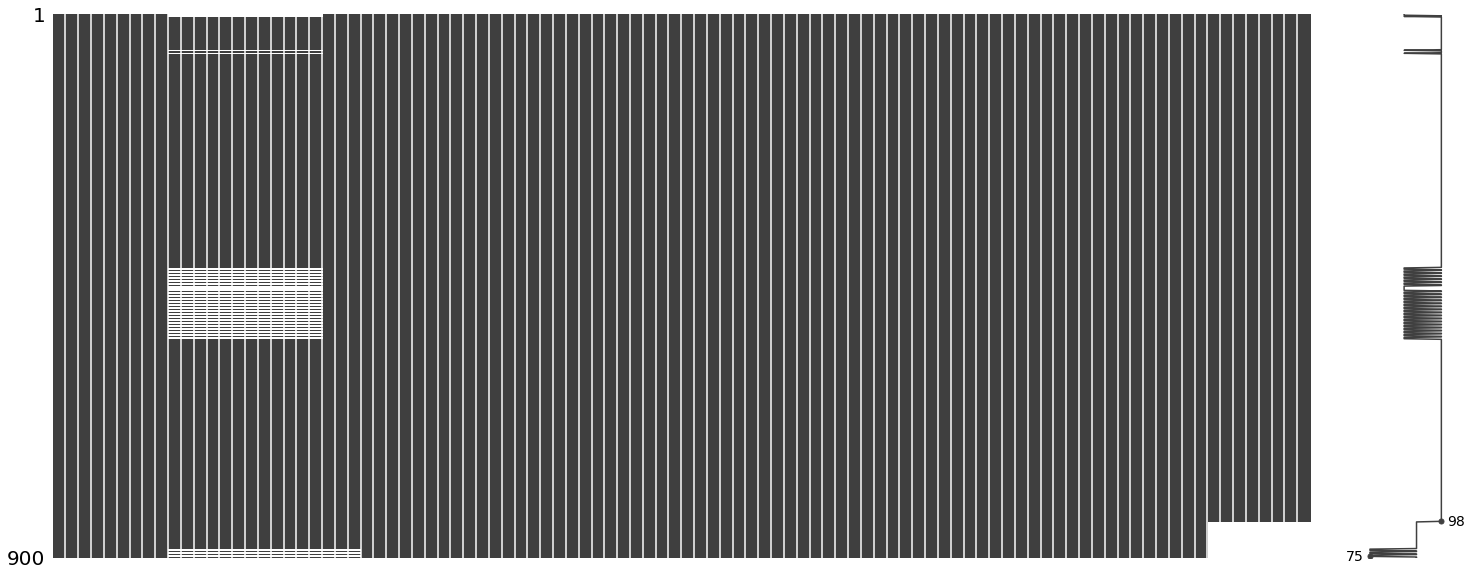

In [93]:
missingno.matrix(dataset)

In [94]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [95]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [96]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [97]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [98]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

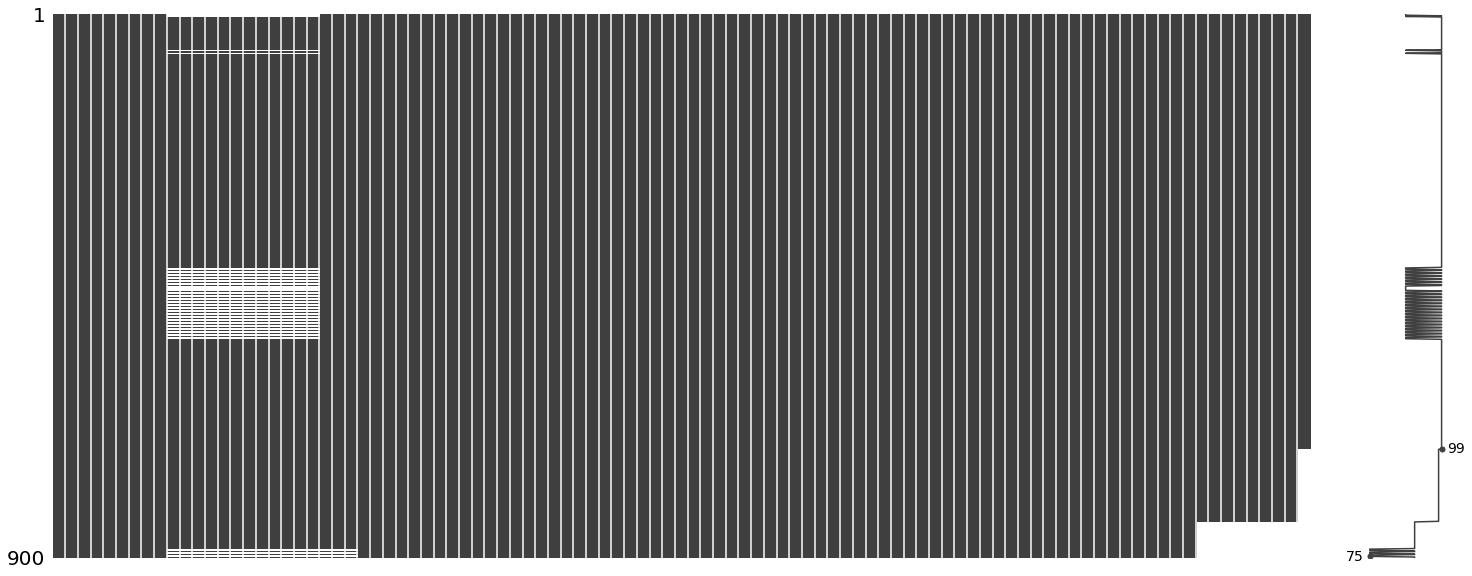

In [99]:
missingno.matrix(dataset)

In [100]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [101]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [102]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [103]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [104]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

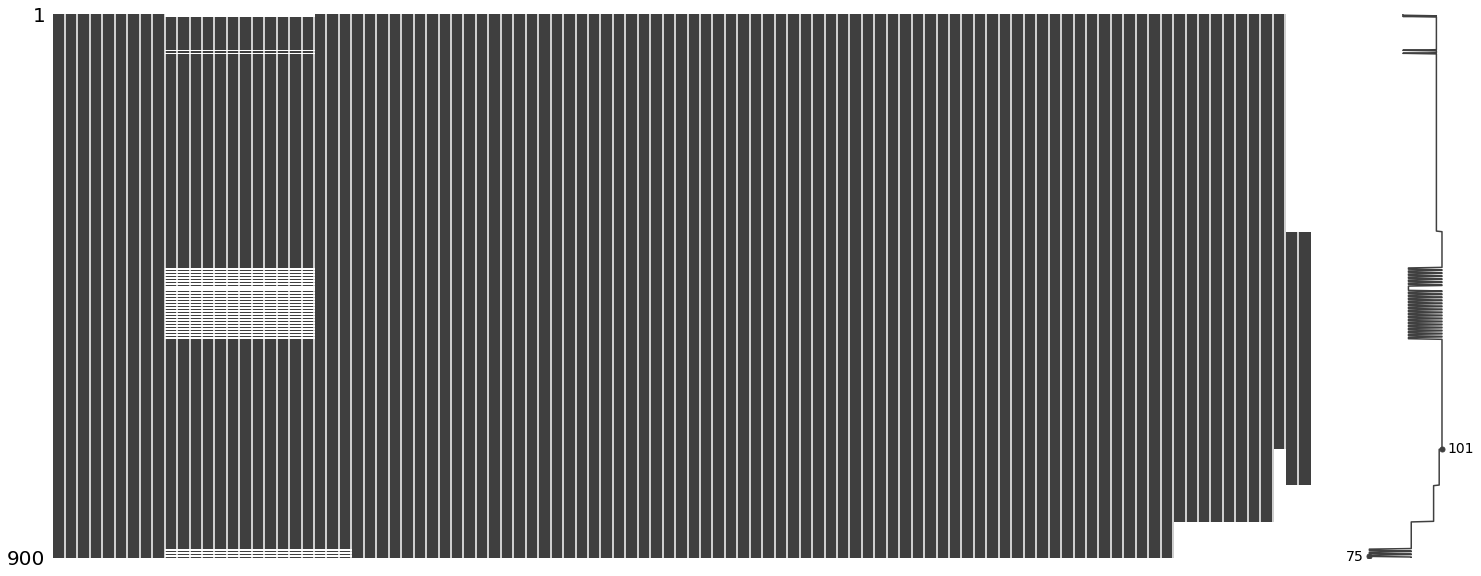

In [105]:
missingno.matrix(dataset)

In [106]:
missing = describe_dataframe(dataset)

In [107]:
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
...,...,...
96,F_Y_GE65,6.666700
97,F_TOTAL,6.666700
98,MIO_EUR,20.000000
99,L_TOTAL,53.333300


In [108]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.293398,-1.643682,1.824858,7.036106,31.387255,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-8.242326,9.934900,218.119280,0,15.333333,21.500000,43.877551,925.726578,41.000000,-8.000000,49.000000,4.333333,26.666667,26.666667,4.333333,1688.000000,361.000000,6.000000,66.840173,765.000000,161.000000,161.000000,765.000000,10968.000000,50216.000000,14937.000000,76121.000000,9925.000000,43408.000000,18383.000000,71716.000000,2311.100000,NaN,NaN
1,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.769895,-1.152583,2.808656,9.791599,31.000000,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2,-5.288987,12.493000,303.539567,0,14.541667,18.916667,46.138211,792.137021,36.000000,-5.000000,41.000000,5.333333,23.833333,24.000000,5.333333,1700.000000,303.000000,30.000000,59.851570,735.000000,222.000000,237.000000,623.000000,10590.000000,37198.000000,7334.000000,55122.000000,9955.000000,36599.000000,9263.000000,55817.000000,1544.090000,NaN,NaN
2,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.184231,-0.670160,3.257036,8.572965,31.000000,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.000000,1.000000,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,31,36,30,12,12,3,5,8,2,-4.623871,12.565323,265.761927,0,15.750000,20.500000,46.590909,890.735141,40.000000,-4.000000,44.000000,5.500000,26.666667,26.666667,5.333333,1648.000000,339.000000,9.000000,66.126590,772.000000,158.000000,158.000000,603.000000,8312.000000,36363.000000,9590.000000,54265.000000,7809.000000,37741.000000,11914.000000,57464.000000,1637.960000,NaN,NaN
3,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,1,2009,0.127943,0.355711,0.247755,-0.355711,0.112507,0.361166,0.255837,-0.361166,0.035535,0.071643,0.097632,0.071643,4.705082,-2.016578,1.3

In [109]:
dataset.reset_index(inplace=True, drop=True)

In [110]:
dataset['cases'].value_counts()

0     837
1      22
3      11
2      10
5       5
7       3
9       2
10      2
4       2
38      1
16      1
6       1
11      1
21      1
23      1
Name: cases, dtype: int64

In [111]:
dataset['cases'].sum()

282

In [112]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.293398,-1.643682,1.824858,7.036106,31.387255,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.000000,1.000000,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-8.242326,9.934900,218.119280,0,15.333333,21.500000,43.877551,925.726578,41.000000,-8.000000,49.000000,4.333333,26.666667,26.666667,4.333333,1688.000000,361.000000,6.000000,66.840173,765.000000,161.000000,161.000000,765.000000,10968.000000,50216.000000,14937.000000,76121.000000,9925.000000,43408.000000,18383.000000,71716.000000,2311.100000,NaN,NaN
1,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.769895,-1.152583,2.808656,9.791599,31.000000,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.000000,1.000000,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2,-5.288987,12.493000,303.539567,0,14.541667,18.916667,46.138211,792.137021,36.000000,-5.000000,41.000000,5.333333,23.833333,24.000000,5.333333,1700.000000,303.000000,30.000000,59.851570,735.000000,222.000000,237.000000,623.000000,10590.000000,37198.000000,7334.000000,55122.000000,9955.000000,36599.000000,9263.000000,55817.000000,1544.090000,NaN,NaN
2,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.184231,-0.670160,3.257036,8.572965,31.000000,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.000000,1.000000,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,31,36,30,12,12,3,5,8,2,-4.623871,12.565323,265.761927,0,15.750000,20.500000,46.590909,890.735141,40.000000,-4.000000,44.000000,5.500000,26.666667,26.666667,5.333333,1648.000000,339.000000,9.000000,66.126590,772.000000,158.000000,158.000000,603.000000,8312.000000,36363.000000,9590.000000,54265.000000,7809.000000,37741.000000,11914.000000,57464.000000,1637.960000,NaN,NaN
3,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,24.180725,41.300798,1,2009,0.127943,0.355711,0.247755,-0.355711,0.112507,0.361166,0.255837,-0.361166,0.035535,0.071643,0.097632,0.071643,4.705082,-2.016578,1.3

In [113]:
cols = dataset.columns

In [114]:
print(cols)


Index(['dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x',
       'y', 'month', 'year', 'ndvi',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=101)


In [115]:
len(cols)

101

In [116]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc, index = False)
